## **1. Basic Dataset Load + Train/Test Split**

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

**Why?**
* A dataset is the raw material of ML
* The train/test split teaches the model generalization.

In [ ]:
# Load dataset as pandas DataFrame (easy analysis)
data = load_breast_cancer(as_frame=True).frame

# Separate features (X) and labels (y)
X, y = load_breast_cancer(return_X_y=True)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## **2. Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

**Why?**
* Algorithms like KNN use distance.
* If the scales are different, the model gets confused.


In [ ]:
scaler = StandardScaler()

# Fit ONLY on training data (important concept)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

## **3. KNN Model Training**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

**Why KNN?**
* Simple baseline model
* Distance-based learning

## **4. Data Visualization (Understanding Data)**

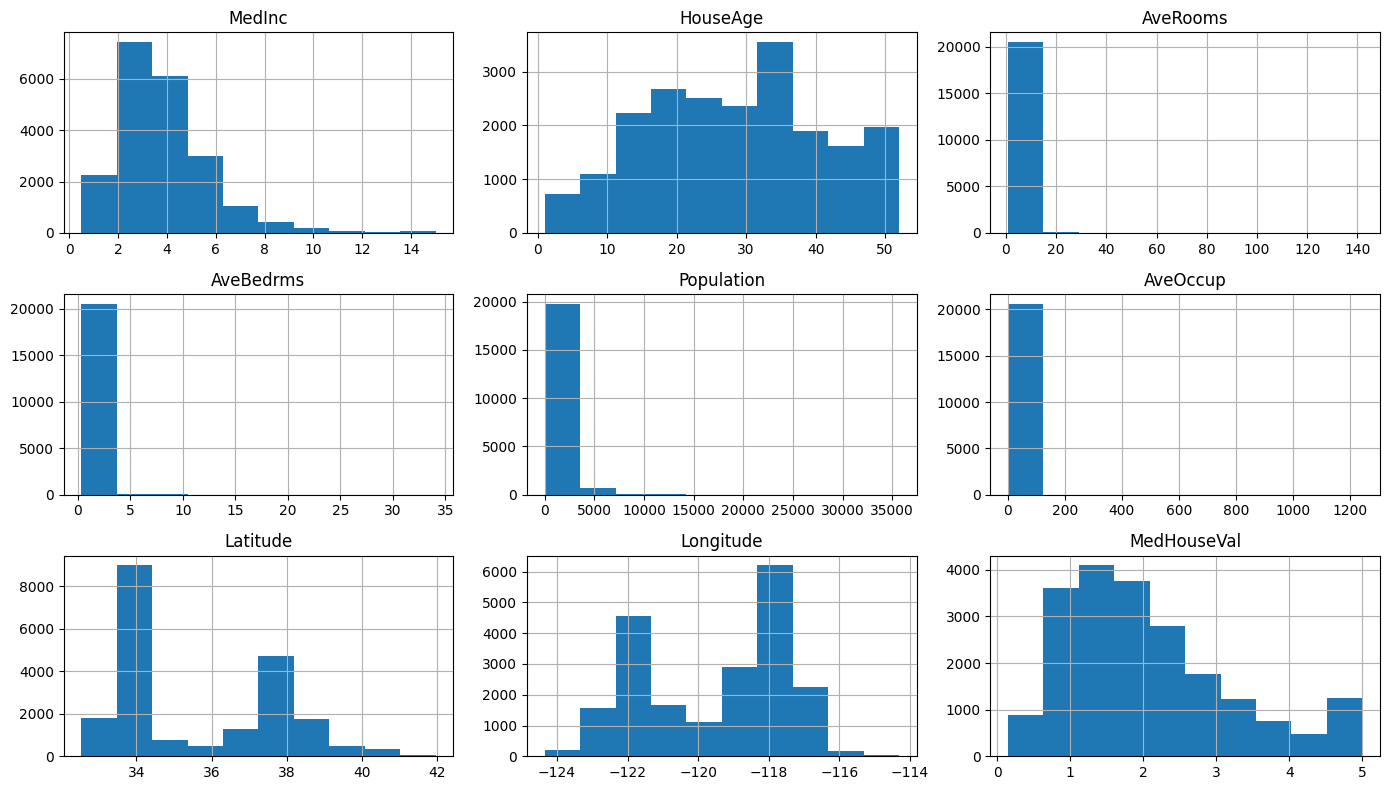

In [ ]:
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

# Load housing dataset
df2 = fetch_california_housing(as_frame=True).frame

# Histograms for feature distribution
df2.hist(figsize=(14,8))
plt.tight_layout()

**Why?**
* Data understanding = 50% ML
* Outliers, skewness detecting

## **5. Synthetic Data**

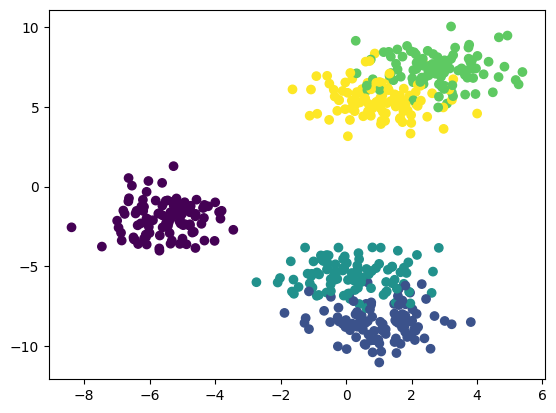

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=500, centers=5)

plt.scatter(X[:,0], X[:,1], c=y)

**Why?**
* Practice + visualization
* Understanding Clustering

## **6. Class Distribution Check**

([<matplotlib.axis.XTick at 0x7dc0c56d9310>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

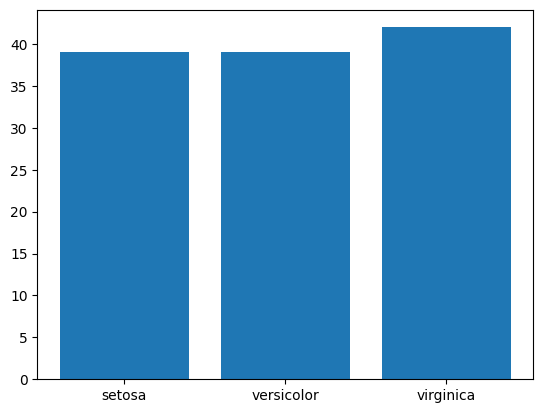

In [ ]:
from sklearn.datasets import load_iris
import numpy as np

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Count samples per class
count = np.bincount(y_train)
position = np.arange(3)

plt.bar(position, count)
plt.xticks(position, data.target_names)

Why?
* To find Imbalanced data

## **7. Categorical Encoding**

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder

# Load dataset
adult = fetch_openml('adult', as_frame=True).frame

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Encode categorical columns
encoded_values = encoder.fit_transform(adult[['occupation', 'race']])

# New column names
new_cols = encoder.get_feature_names_out(['occupation', 'race'])

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name adult exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=179
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1590

  warn(warning_msg)


**Why?**
* Because ML models undersand only  numbers
* Categories → numeric form

## **8. PCA (Dimensionality Reduction)**

In [ ]:
from sklearn.decomposition import PCA

# MNIST dataset (784 features)
X, y = fetch_openml('mnist_784', return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pca = PCA(n_components=10)

# Reduce dimensions
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

**Why?**
* Speed increase
* Noise reduction
* Overfitting reduction

## **9. Random Forest Model**


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier()
clf.fit(X_train_scaled, y_train)

RandomForestClassifier()

**Why?**
* Powerful ensemble model
* Overfitting reduction

## **10. Hyperparameter Tuning**


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

clf = RandomForestClassifier(n_jobs=-1)
grid = GridSearchCV(clf, param_grid, cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]})

**Why?**
* Finding the best parameters automatically is typically done through Hyperparameter Optimization.

## **11. Pipeline**

In [ ]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('forest', RandomForestClassifier())
])

pipe.fit(X_train, y_train)

Pipeline(steps=[('scale', StandardScaler()), ('pca', PCA(n_components=10)),
                ('forest', RandomForestClassifier())])

**Why?**
* Clean code
* No data leakage
* Production-ready

In [ ]:
y_pred = pipe.predict(X_test)


## **12. Evaluation Metrics (Precision, Recall, F1)**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

precision, recall, f1

(1.0, 1.0, 1.0)

**Why?**
* Accuracy is not always useful.
* Precision → Controls False Positives.
* Recall → Controls False Negatives.
* F1 Score → Balance between Precision and Recall.

## **13. Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

# Example using RandomForest
scores = cross_val_score(clf, X_train, y_train, cv=5)

scores
scores.mean()

np.float64(0.9582417582417582)

**Why?**
* It does not depend on a single split.
* It shows the true performance of the model.


### **In this notebook, I implemented a complete end-to-end Machine Learning workflow using Scikit-learn, covering:**

✅ Data preprocessing and cleaning  
✅ Feature scaling (Standardization)  
✅ Categorical encoding (One-Hot Encoding)  
✅ Dimensionality reduction using PCA  
✅Model training (KNN, Random Forest)  
✅Hyperparameter tuning using GridSearchCV  
✅ Pipeline creation for production-ready workflows  
✅ Model evaluation using Precision, Recall, F1-score  
✅ Model validation using Cross-Validation  


This demonstrates a strong foundation in building scalable and reliable ML systems.Ensured no data leakage using proper train-test separation and pipelines.
